# 03 Entrenamiento y comparacion de modelos

Este notebook toma el rol de `experiments.ipynb` del repo de referencia, pero aplicado a series mensuales de productos. Aqui se entrenan exclusivamente modelos de Machine Learning.

Modelos evaluados:

- `hist_gradient_boosting`: modelo principal.
- `hist_gradient_boosting_tuned`: Gradient Boosting con tuning de hiperparametros.
- `random_forest`: bosque aleatorio no lineal.
- `random_forest_conservative`: bosque aleatorio mas regularizado para reducir sobreajuste.
- `extra_trees`: ensamble de arboles extremadamente aleatorizados.
- `linear_regression`: regresion lineal.
- `ridge_regression`: regresion lineal regularizada.
- `sgd_gradient_regression`: regresion lineal ajustada con descenso por gradiente.
La metrica principal para comparar es WAPE: error absoluto total dividido para volumen real total.

La seleccion final usa `forecast_model: best_ml_stable`, que escoge el modelo ML con mejor balance entre validacion y test historico.

Si se completan las plantillas de variables exogenas, esas columnas entran como features adicionales del modelo.

In [1]:
from pathlib import Path
import sys
from io import StringIO

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

def find_project_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "config" / "config.yml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del proyecto. Abre VS Code en la carpeta 'Avance 3'.")

ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)
plt.style.use("default")

from quickbooks_forecast.config import load_config

config = load_config()
reports_dir = config["resolved_paths"]["reports_dir"]
processed_dir = config["resolved_paths"]["processed_dir"]
raw_dir = config["resolved_paths"]["raw_dir"]
images_dir = ROOT / "notebooks" / "images"
images_dir.mkdir(parents=True, exist_ok=True)

def save_fig(name, extension="png", resolution=160):
    path_final = images_dir / f"{name}.{extension}"
    plt.tight_layout()
    plt.savefig(path_final, dpi=resolution, bbox_inches="tight")
    print(f"Figura guardada: {path_final}")

**Preparacion del entrenamiento:**

Este bloque prepara el entorno de entrenamiento. Desde aqui se usan los datasets limpios y las mismas configuraciones del pipeline automatizado.

In [2]:
from quickbooks_forecast.modeling import train_all

artifacts = train_all(config)
print("Modelos entrenados:", list(artifacts))

C:\Users\Tony\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modelos entrenados: ['PT', 'PP']


**Entrenamiento de modelos ML:**

Se entrenan modelos separados para PT y PP. Todos los candidatos son modelos de Machine Learning; los promedios moviles o reglas simples no se usan como modelo final.

In [3]:
comparison = pd.read_csv(reports_dir / "model_comparison_all.csv")
validation = pd.read_csv(reports_dir / "validation_model_comparison_all.csv")
tuning = pd.read_csv(reports_dir / "hgb_tuning_all.csv")

print("Comparacion en validacion")
display(validation.sort_values(["source", "rank_wape"]))
print("Comparacion en test")
display(comparison.sort_values(["source", "rank_wape"]))
print("Mejores hiperparametros HGB por tipo")
display(tuning.sort_values(["source", "rank_validation"]).groupby("source").head(1))

Comparacion en validacion


,mae,rmse,smape,wape,source,model_name,split,rows,period_from,period_until,selected_for_forecast,rank_wape
8,637.688852,4203.336073,0.037878,0.077358,PP,random_forest,validation,677,2025-09-01,2025-11-01,True,1
9,640.178111,4623.750589,0.045956,0.077660,PP,extra_trees,validation,677,2025-09-01,2025-11-01,False,2
10,763.851962,4225.403603,0.432302,0.092663,PP,hist_gradient_boosting_tuned,validation,677,2025-09-01,2025-11-01,False,3
11,825.061789,6881.925331,0.046290,0.100089,PP,random_forest_conservative,validation,677,2025-09-01,2025-11-01,False,4
12,1009.625650,6872.787347,0.434739,0.122478,PP,hist_gradient_boosting,validation,677,2025-09-01,2025-11-01,False,5
13,6129.660502,33198.133179,0.763685,0.743592,PP,sgd_gradient_regression,validation,677,2025-09-01,2025-11-01,False,6
14,7987.594640,42997.613643,0.689144,0.968979,PP,ridge_regression,validation,677,2025-09-01,2025-11-01,False,7
15,10879.839196,65964.913817,0.721865,1.319838,PP,linear_regression,validation,677,2025-09-01,2025-11-01,False,8
0,307.663657,1307.910524,0.052575,0.072424,PT,random_forest,validation,2378,2025-10-01,2025-12-01,True,1
1,318.640403,1298.256011,0.053360,0.075008,PT,random_forest_conservative,validation,2378,2025-10-01,2025-12-01,False,2


Comparacion en test


,mae,rmse,smape,wape,source,model_name,split,rows,period_from,period_until,selected_for_forecast,rank_wape
8,386.982709,1278.367652,0.039346,0.054517,PP,extra_trees,test,677,2025-12-01,2026-02-01,False,1
9,426.363831,1546.521464,0.032483,0.060065,PP,random_forest,test,677,2025-12-01,2026-02-01,True,2
10,476.626270,1746.175541,0.037208,0.067146,PP,random_forest_conservative,test,677,2025-12-01,2026-02-01,False,3
11,515.969953,2064.877110,0.360643,0.072689,PP,hist_gradient_boosting_tuned,test,677,2025-12-01,2026-02-01,False,4
12,573.564687,3658.867156,0.485774,0.080802,PP,hist_gradient_boosting,test,677,2025-12-01,2026-02-01,False,5
13,6844.324374,47237.577141,0.703041,0.964212,PP,linear_regression,test,677,2025-12-01,2026-02-01,False,6
14,7703.910993,51036.102522,0.706134,1.085308,PP,ridge_regression,test,677,2025-12-01,2026-02-01,False,7
15,9354.453834,64338.892801,0.608260,1.317833,PP,sgd_gradient_regression,test,677,2025-12-01,2026-02-01,False,8
0,186.122513,572.948662,0.044238,0.058044,PT,random_forest,test,2384,2026-01-01,2026-03-01,True,1
1,194.592343,561.613299,0.137489,0.060685,PT,extra_trees,test,2384,2026-01-01,2026-03-01,False,2


Mejores hiperparametros HGB por tipo


,source,candidate,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,mae,rmse,smape,wape,rows_train,rows_validation,split,folds,period_from,period_until,rank_validation
7,PP,7,0.03,500,31,10,0.0,720.611196,4811.704805,0.418970,0.093736,1422,1923,temporal_cv,3,2025-03-01,2025-11-01,1
0,PT,4,0.08,250,31,30,0.1,294.764897,1802.871442,0.324126,0.080839,18198,6949,temporal_cv,3,2025-04-01,2025-12-01,1


**Seleccion por validacion temporal:**

Esta comparacion justifica el criterio de seleccion. El modelo elegido no se escoge a mano: se compara por WAPE en validacion temporal y test historico.

Figura guardada: F:\proyecto-integrador\Avance 3\Modelado\forecasting_v3\notebooks\images\03_comparacion_modelos_wape.png


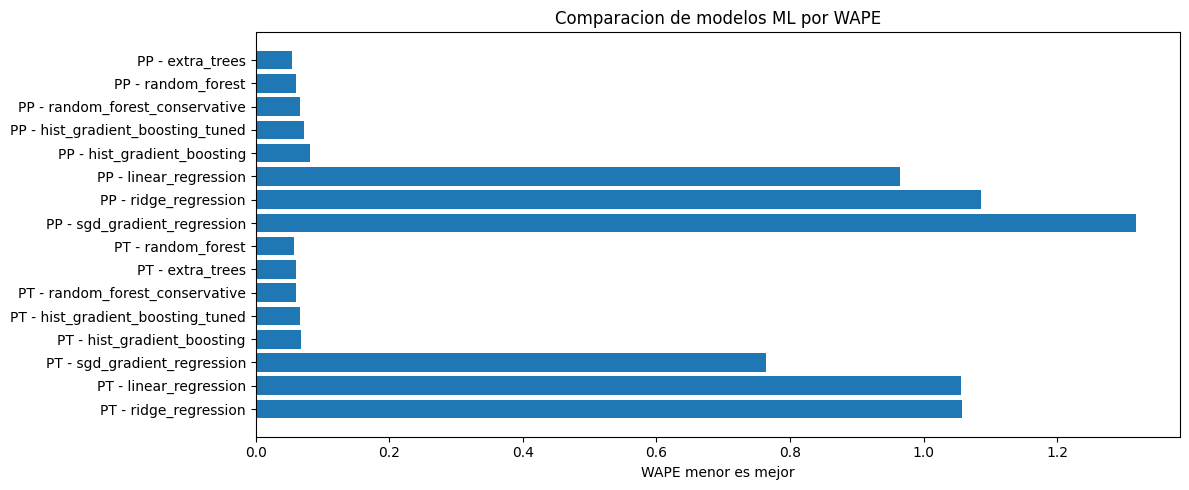

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_data = comparison.sort_values(["source", "wape"]).copy()
labels = plot_data["source"] + " - " + plot_data["model_name"]
ax.barh(labels, plot_data["wape"])
ax.set_title("Comparacion de modelos ML por WAPE")
ax.set_xlabel("WAPE menor es mejor")
ax.invert_yaxis()
save_fig("03_comparacion_modelos_wape")
plt.show()

**Comparacion visual de modelos:**

La grafica facilita explicar que modelos no lineales, especialmente Random Forest, capturan mejor patrones de producto, temporada y variables exogenas.

In [5]:
metrics_pt = pd.read_csv(reports_dir / "metrics_pt.csv")
metrics_pp = pd.read_csv(reports_dir / "metrics_pp.csv")

print("Metricas modelo principal PT")
display(metrics_pt)
print("Metricas modelo principal PP")
display(metrics_pp)

Metricas modelo principal PT


,mae,rmse,smape,wape,source,selected_model_name,selection_metric,train_rows,pre_test_rows,validation_rows,test_rows,train_until,pre_test_until,validation_from,validation_until,test_from,test_until
0,186.122513,572.948662,0.044238,0.058044,PT,random_forest,wape,22769,25147,2378,2384,2025-09-01,2025-12-01,2025-10-01,2025-12-01,2026-01-01,2026-03-01


Metricas modelo principal PP


,mae,rmse,smape,wape,source,selected_model_name,selection_metric,train_rows,pre_test_rows,validation_rows,test_rows,train_until,pre_test_until,validation_from,validation_until,test_from,test_until
0,426.363831,1546.521464,0.032483,0.060065,PP,random_forest,wape,2668,3345,677,677,2025-08-01,2025-11-01,2025-09-01,2025-11-01,2025-12-01,2026-02-01


**Metricas finales del modelo:**

Estas son las metricas principales para la presentacion. Con el escenario `replacement`, PT y PP quedan cerca del rango 5%-7% WAPE requerido para evaluar reemplazo asistido de la planificacion humana.

In [6]:
high_error = pd.read_csv(reports_dir / "high_error_products_all.csv")
display(
    high_error[
        [
            "source_type",
            "product_id",
            "product_name",
            "cantidad_real_total",
            "cantidad_predicha_total",
            "error_absoluto_total",
            "wape_producto",
            "prioridad_revision",
        ]
    ].head(40)
)

,source_type,product_id,product_name,cantidad_real_total,cantidad_predicha_total,error_absoluto_total,wape_producto,prioridad_revision
0,PT,PT_4841,EL ARTESANAL ACEITE GIRASOL 1L (4841),95346.0,107331.181689,11985.181689,0.125702,alta
1,PT,PT_3058,EL ARTESANAL ACEITE VEGETAL 1L (3058),139094.0,129511.801211,9582.198789,0.068890,alta
2,PT,PT_4841,EL ARTESANAL ACEITE GIRASOL 1L (4841),118546.0,114024.376565,8191.033833,0.069096,alta
3,PT,PT_4715,* EL ARTESANAL ACEITE OLIVA EXTRA VIRGEN 250 M...,84507.0,76434.415480,8072.584520,0.095526,alta
4,PT,PT_8608,* ALINO BOT 310 GRS. (8608),88555.0,91944.371228,6155.676473,0.069512,alta
...,...,...,...,...,...,...,...,...
35,PT,PT_1722,AJO PASTA BOT 470 GRS(1722),30781.0,31671.950800,2194.371886,0.071290,alta
36,PT,PT_9060,* ALINO FDA 200 GRS. (9060),24379.0,26569.755647,2190.755647,0.089862,alta
37,PT,PT_1722,AJO PASTA BOT 470 GRS(1722),16592.0,18713.108466,2121.108466,0.127839,alta
38,PT,PT_9053,* ALINO FDA 400 GRS. (9053),20449.0,22563.360187,2114.360187,0.103397,alta


**Priorizacion de productos con error:**

Esta tabla convierte el error en accion operativa: identifica productos que no deben automatizarse sin revision de produccion o comercial.

In [7]:
backtest_pt = pd.read_csv(reports_dir / "backtest_pt.csv", parse_dates=["periodo"])
backtest_pp = pd.read_csv(reports_dir / "backtest_pp.csv", parse_dates=["periodo"])

print("Backtest PT")
display(backtest_pt.head())
print("Backtest PP")
display(backtest_pp.head())

Backtest PT


,source_type,product_id,product_name,periodo,target_qty,estado_producto,es_estacional,meses_estacionales,prediction_extra_trees,abs_error_extra_trees,prediction_hist_gradient_boosting,abs_error_hist_gradient_boosting,prediction_hist_gradient_boosting_tuned,abs_error_hist_gradient_boosting_tuned,prediction_linear_regression,abs_error_linear_regression,prediction_random_forest,abs_error_random_forest,prediction_random_forest_conservative,abs_error_random_forest_conservative,prediction_ridge_regression,abs_error_ridge_regression,prediction_sgd_gradient_regression,abs_error_sgd_gradient_regression
0,PT,PT_0000,SAZONADOR AZAFRAN KILO (0000),2026-01-01,20.0,activo,False,"octubre, julio, febrero",21.893193,1.893193,22.639615,2.639615,22.692075,2.692075,17.291463,2.708537,22.443733,2.443733,22.715575,2.715575,17.244784,2.755216,23.008342,3.008342
1,PT,PT_0000,SAZONADOR AZAFRAN KILO (0000),2026-02-01,0.0,activo,False,"enero, octubre, julio",0.000000,0.000000,0.002953,0.002953,0.003810,0.003810,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,PT,PT_0000,SAZONADOR AZAFRAN KILO (0000),2026-03-01,8.0,activo,False,"enero, octubre, julio",7.481856,0.518144,7.729989,0.270011,7.747040,0.252960,93.000000,85.000000,7.557603,0.442397,7.609031,0.390969,93.000000,85.000000,93.000000,85.000000
3,PT,PT_0015,MANI PAST FDA 200 GRS(0015),2026-01-01,1396.0,activo,False,"abril, marzo, febrero",1338.478714,57.521286,1302.072744,93.927256,1289.442661,106.557339,2468.017413,1072.017413,1391.078319,4.921681,1398.093391,2.093391,2475.856709,1079.856709,2057.892223,661.892223
4,PT,PT_0015,MANI PAST FDA 200 GRS(0015),2026-02-01,2604.0,activo,False,"abril, marzo, febrero",2955.492414,351.492414,2984.491787,380.491787,2948.615086,344.615086,2234.621470,369.378530,2936.435497,332.435497,2973.493883,369.493883,2208.012051,395.987949,1978.226098,625.773902


Backtest PP


,source_type,product_id,product_name,periodo,target_qty,estado_producto,es_estacional,meses_estacionales,prediction_extra_trees,abs_error_extra_trees,prediction_hist_gradient_boosting,abs_error_hist_gradient_boosting,prediction_hist_gradient_boosting_tuned,abs_error_hist_gradient_boosting_tuned,prediction_linear_regression,abs_error_linear_regression,prediction_random_forest,abs_error_random_forest,prediction_random_forest_conservative,abs_error_random_forest_conservative,prediction_ridge_regression,abs_error_ridge_regression,prediction_sgd_gradient_regression,abs_error_sgd_gradient_regression
0,PP,PP_01396889e6,MOSTAZA PRODUCCIÓN GRANEL,2025-12-01,9727.52,activo,False,"septiembre, agosto, noviembre",9548.454444,179.065556,9356.338315,371.181685,9369.289346,358.230654,1067.396404,8660.123596,9523.914554,203.605446,9423.827913,303.692087,1056.865990,8670.654010,1033.130871,8694.389129
1,PP,PP_01396889e6,MOSTAZA PRODUCCIÓN GRANEL,2026-01-01,8138.59,activo,False,"septiembre, agosto, diciembre",7597.833074,540.756926,7698.674821,439.915179,7639.170320,499.419680,1413.135662,6725.454338,7696.371859,442.218141,7778.830648,359.759352,1361.812644,6776.777356,898.454156,7240.135844
2,PP,PP_01396889e6,MOSTAZA PRODUCCIÓN GRANEL,2026-02-01,4851.96,activo,False,"enero, septiembre, agosto",5123.506538,271.546538,5150.132423,298.172423,5011.057193,159.097193,2470.363324,2381.596676,5075.444765,223.484765,5211.336694,359.376694,2366.882820,2485.077180,1802.842941,3049.117059
3,PP,PP_021ba1ac93,* ALINO COMPLETO KILOS GRANEL,2025-12-01,0.00,activo,False,"octubre, noviembre, julio",0.000000,0.000000,0.000000,0.000000,0.005780,0.005780,15.978176,15.978176,0.000000,0.000000,0.000000,0.000000,30.689928,30.689928,34.671969,34.671969
4,PP,PP_021ba1ac93,* ALINO COMPLETO KILOS GRANEL,2026-01-01,93676.00,activo,False,"octubre, noviembre, julio",97281.217516,3605.217516,116012.716748,22336.716748,104648.657067,10972.657067,134559.652054,40883.652054,96695.855029,3019.855029,97055.295154,3379.295154,475621.074657,381945.074657,892749.319498,799073.319498


**Backtest historico producto-mes:**

El backtest muestra prediccion contra valor real en meses historicos no usados como entrenamiento final. Esto permite defender que la evaluacion respeta el tiempo.

Figura guardada: F:\proyecto-integrador\Avance 3\Modelado\forecasting_v3\notebooks\images\03_productos_mayor_error.png


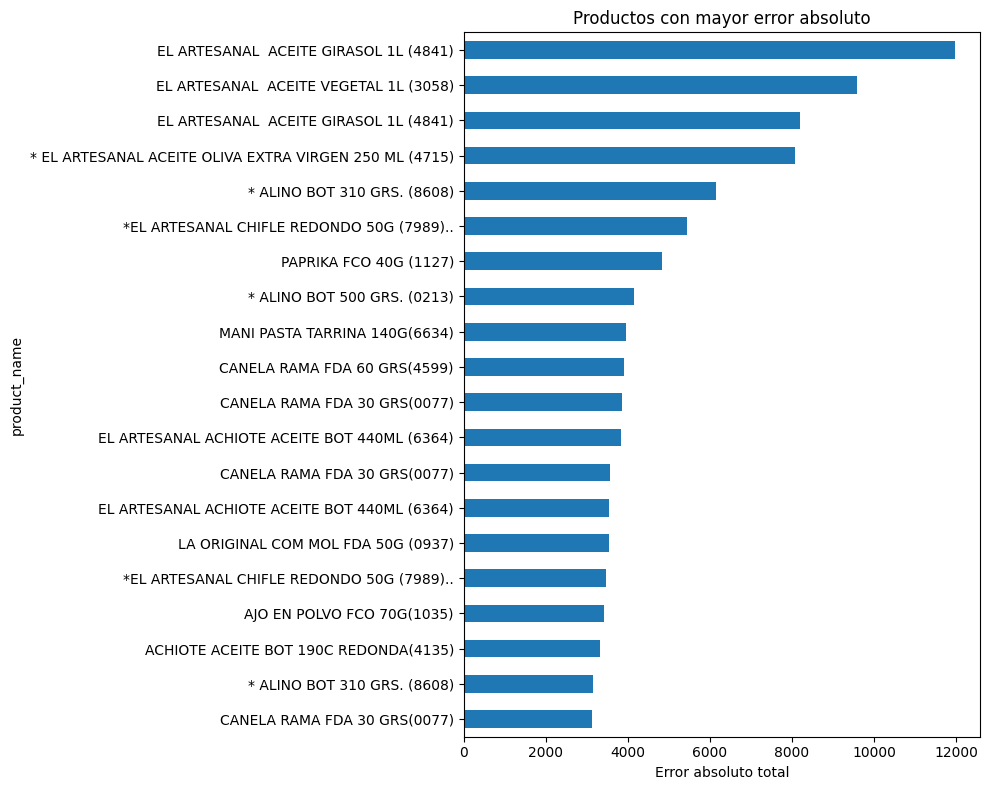

In [8]:
high_error.head(20).plot(
    kind="barh",
    x="product_name",
    y="error_absoluto_total",
    figsize=(10, 8),
    legend=False,
    title="Productos con mayor error absoluto",
)
plt.xlabel("Error absoluto total")
plt.gca().invert_yaxis()
save_fig("03_productos_mayor_error")
plt.show()

**Riesgo concentrado por producto:**

Los productos con mayor error absoluto concentran el riesgo de decision. Para automatizar, estos casos deben quedar marcados como revision obligatoria.

Lectura sugerida:

- El modelo seleccionado debe ser ML; los metodos estadisticos simples no se usan como candidato final.
- Si regresion lineal o SGD tienen errores altos, se descartan frente a modelos ML no lineales.
- Si Gradient Boosting tuneado no mejora, se comparan Random Forest y Extra Trees como alternativas ML no lineales.
- La seleccion final conserva el ML mas estable por validacion/test.
- Para bajar el error de forma fuerte, completar variables exogenas historicas y futuras conocidas antes del mes.
- El modo `--replacement-demo` del generador de exogenas sirve como escenario asistido: simula que pedidos/preventas/ajustes contienen una propuesta humana conocida antes del mes y debe reemplazarse por datos reales para una validacion oficial.
- Los productos de mayor error deben validarse con produccion/comercial antes de tomar decisiones.